In [1]:
import pandas as pd
path = "diabetes.csv"
df = pd.read_csv(path)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
columns_to_analyze = ['Glucose', 'BloodPressure', 'BMI']

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

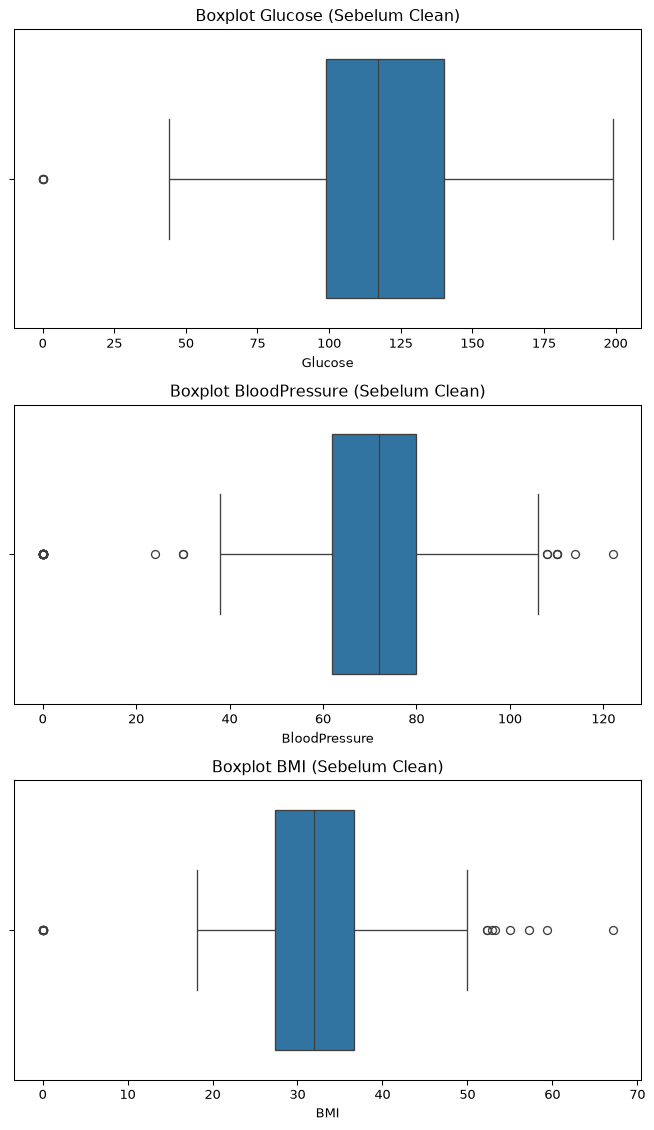

In [8]:
fig, axs = plt.subplots(len(columns_to_analyze), 1, figsize=(7, 4 * len(columns_to_analyze)), dpi=95)

for i, col in enumerate(columns_to_analyze):
    sns.boxplot(x=df[col], ax=axs[i])
    axs[i].set_title(f'Boxplot {col} (Sebelum Clean)')

plt.tight_layout()
plt.show()

In [15]:
def remove_outliers_sequentially(dataframe, columns):
    df_cleaned = dataframe.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col].dropna(), [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

In [18]:
import numpy as np

In [19]:
clean_data = remove_outliers_sequentially(df, columns_to_analyze)

print(f"Data berhasil dibersihkan! Jumlah baris awal: {len(df)} | Setelah bersih: {len(clean_data)}")

Data berhasil dibersihkan! Jumlah baris awal: 768 | Setelah bersih: 709


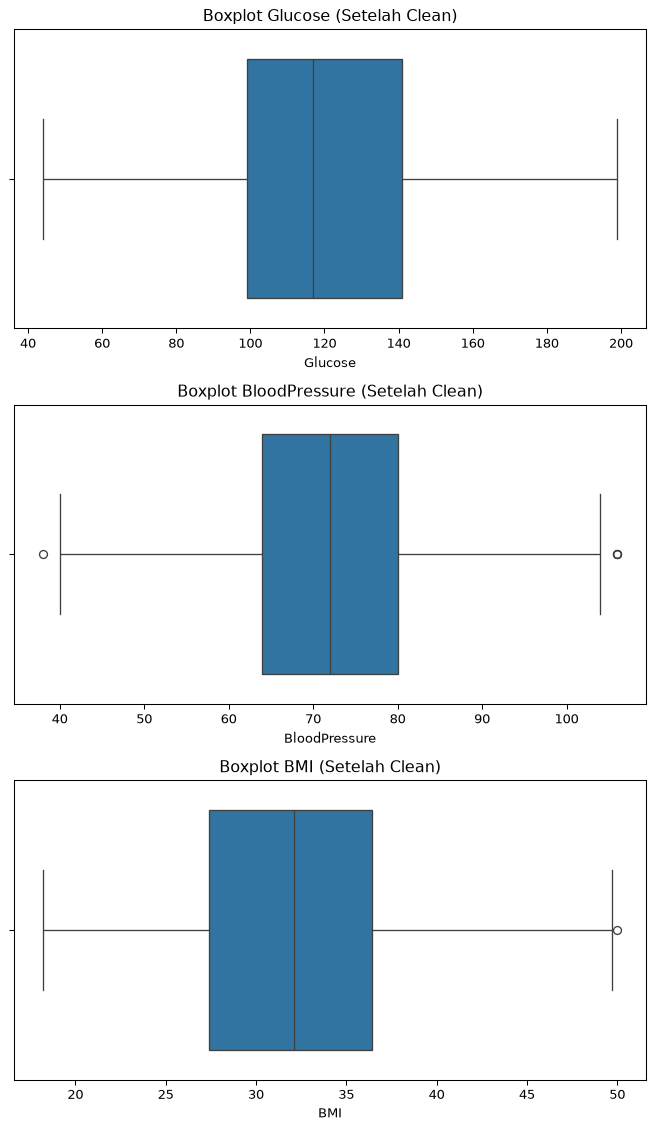

In [20]:
fig, axs = plt.subplots(len(columns_to_analyze), 1, figsize=(7, 4 * len(columns_to_analyze)), dpi=95)

for i, col in enumerate(columns_to_analyze):
    sns.boxplot(x=clean_data[col], ax=axs[i])
    axs[i].set_title(f'Boxplot {col} (Setelah Clean)')

plt.tight_layout()
plt.show()